# Extension de modelo WPEB - Resolucion con metaheuristicas

Este google colab presenta un modelo extendido WPEB, el cual nacio en base al modelo planteado en el paper:

[**Li et al. (2024)**, Capacity optimization of a wind-photovoltaic-electrolysis-battery (WPEB) hybrid energy system for power and hydrogen generation.](https://www.sciencedirect.com/science/article/abs/pii/S0360319923039812)

El paper original formula un método de optimización de capacidad de único objetivo con múltiples restricciones para un sistema WPEB a escala de utilidad (>10 MW), cuyo objetivo es minimizar el **LCOE** (Levelized Cost of Electricity). El modelo base resuelve el problema mediante una simulación de producción de 8760 horas anuales combinada con un método de descenso de gradiente.

## Extensiones respecto al modelo original

Este trabajo introduce tres modificaciones que amplían el espacio de búsqueda del problema:

| Aspecto | Modelo original (paper) | Modelo extendido (este trabajo) |
|---|---|---|
| Capacidad del electrolizador | Variable continua en MW | Variable entera: N° de módulos de 5 MW |
| Potencia de la batería | Fija en 30% de la capacidad del electrolizador | Variable independiente, múltiplos de 5 MW |
| Duración de la batería | Fija en 1 hora | Variable discreta: {1, 2, 4} horas |
| Método de optimización | Grid search + descenso de gradiente | Metaheurísticas híbridas: GWO, PSO, DE |

Estas modificaciones convierten el problema en un problema de optimización mixto (variables continuas y discretas simultáneamente), para el cual se aplican tres metaheurísticas en su versión híbrida: los algoritmos operan en un espacio continuo internamente y proyectan cada solución al espacio discreto válido en el momento de la evaluación, mediante la función `decode_solution`.

El notebook se organiza en cinco secciones:
1. Importación de librerías y definición de parámetros
2. Definición del modelo físico y económico
3. Obtención de datos climáticos
4. Declaración de las metaheurísticas
5. Resolución y comparación de resultados


## **1- Importacion de librerias y definicion de parametros**

### Librerías

Se importan las librerías necesarias para el funcionamiento del modelo:

- **`numpy`** y **`pandas`**: cálculo numérico vectorizado y manejo de datos tabulares (los 8760 registros horarios del año típico).
- **`matplotlib`**: visualización de curvas de convergencia y resultados.
- **`scipy.stats.pearsonr`**: cálculo del coeficiente de correlación de Pearson para la selección del año meteorológico típico.
- **`dataclasses`**: definición estructurada del resultado de la simulación mediante el decorador `@dataclass`.
- **`tqdm`**: barra de progreso durante la descarga de datos meteorológicos.

### Parámetros (`CONFIG` y `COSTS`)

Todos los parámetros del modelo se centralizan en dos diccionarios:

- **`CONFIG`**: parámetros físicos, restricciones del sistema e hiperparámetros de las metaheurísticas. Los valores de componentes (eficiencias, velocidades de corte, temperatura NOCT, etc.) provienen directamente de la **Tabla 3** del paper. Las restricciones operativas (AGSR ≤ 20%, capacidad total = 200 MW, electrolizador ≤ 50% de la capacidad total) corresponden a la **Ecuación (6)**.

- **`COSTS`**: costos de CAPEX, reemplazo y O&M por tecnología, tomados de la **Tabla 4** del paper. Las unidades son CNY (yuan chino) por kW instalado o por kW por año.


In [ ]:
!pip -q install requests pandas numpy matplotlib scipy tqdm

In [1]:
import copy
import math
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, asdict
from typing import Dict, Tuple, List, Optional
from scipy.stats import pearsonr
from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

c:\Users\Abduzcan0\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG = {
    # Coordenadas aproximadas de Damao Banner (ajustables)
    "lat": 41.70,
    "lon": 110.43,

    "start_year": 2001,
    "end_year": 2021,

    "analysis_year_for_8760": None,  # si es None, se escoge automáticamente por complementariedad

    # Restricciones del paper
    "total_generation_capacity_mw": 200.0,
    "agsr_max": 0.20,
    "electrolyzer_ratio_max": 0.50,  # E <= 0.5 * (Wind + PV)

    # Resolución de la búsqueda
    "wind_step_mw": 10.0,     # el paper acelera luego a 10 MW
    "electrolyzer_step_mw": 5.0,

    # Electrólizador modular
    "electrolyzer_unit_mw": 5.0,
    "min_electrolyzer_units": 10,   # 50 MW
    "max_electrolyzer_units": 20,   # 100 MW

    # Batería discreta
    "battery_power_step_mw": 5.0,
    "battery_power_min_mw": 0.0,
    "battery_power_max_mw": 50.0,
    "battery_duration_candidates_h": [1.0, 2.0, 4.0],

    # Supuestos físicos / energéticos
    "h2_hhv_kwh_per_kg": 39.4,  # HHV aproximado
    "electrolyzer_efficiency": 0.75,
    "electrolyzer_min_load_ratio": 0.30,

    # Descuento / horizonte
    "project_lifetime_years": 25,
    "real_discount_rate": 0.0435,  # paper

    # Componentes del paper
    "wind_turbine_rated_mw": 5.0,
    "wind_cut_in_ms": 2.5,
    "wind_rated_ms": 10.5,
    "wind_cut_out_ms": 25.0,

    "pv_dc_ac_ratio": 1.2,
    "pv_temp_coeff_pct_per_c": -0.5,
    "pv_noct_c": 47.0,
    "pv_stc_efficiency_pct": 13.0,
    "pv_derating_factor": 0.90,

    "converter_efficiency": 0.95,
    "battery_roundtrip_efficiency": 0.90,

    # Hiperparametros GWO
    "gwo_population": 20,
    "gwo_iterations": 50,

    # Hiperparametros PSO
    "pso_population" : 20,
    "pso_iterations" : 50,
    "pso_w_min" : 0.4,
    "pso_w_max" : 0.9,
    "pso_c1" : 2.0,
    "pso_c2" : 2.0,

    # Hiperparametros DE
    "de_population" : 20,
    "de_iterations" : 50,
    "de_f_mutation" : 0.8,
    "de_cr" : 0.9,

    # Seed establecida para la generacion random
    "random_seed": 42,
}

COSTS = {
    # Costos del paper (CNY)
    "wind_capex_cny_per_kw": 5917.0,
    "wind_replacement_cny_per_kw": 0.0,
    "wind_om_cny_per_kw_year": 40.2,
    "wind_life_years": 25,

    "pv_capex_cny_per_kw": 4633.0,
    "pv_replacement_cny_per_kw": 0.0,
    "pv_om_cny_per_kw_year": 17.6,
    "pv_life_years": 25,

    "electrolyzer_capex_cny_per_kw": 6964.0,
    "electrolyzer_replacement_cny_per_kw": 5969.14,
    "electrolyzer_om_cny_per_kw_year": 208.92,
    "electrolyzer_life_years": 15,

    "battery_capex_cny_per_kw": 2549.0,
    "battery_replacement_cny_per_kw": 500.0,
    "battery_om_cny_per_kw_year": 10.0,
    "battery_life_years": 10,

    # En el paper el almacenamiento H2 se da por kg.
    # Aquí se deja opcional; para la línea base lo mantenemos fuera del LCOE
    # porque el paper no explicita en detalle la capacidad óptima de este subsistema
    # dentro del barrido principal del W/P/E/B.
    "hydrogen_storage_capex_cny_per_kg": 6611.77,
    "hydrogen_storage_om_cny_per_kg_year": 141.68,
    "hydrogen_storage_life_years": 25,
}

## **2 - Definicion del modelo**

En este bloque se define el modelo en general, y las respectivas funciones para que este funcione. Entre ellas encontramos el funcionamiento del modelo fotovoltaico y eolico, ademas del economico, para despues utilizarlos en el WPEB.


### 1.1 - Modelo fotovoltaico

In [3]:
def pv_power_mw(df: pd.DataFrame, pv_ac_capacity_mw: float, config: Dict) -> np.ndarray:
    ghi = df["ghi_kwh_m2"].values  # kWh/m2 por hora ~ kW/m2 promedio horario
    t_amb = df["t2m_c"].values

    # Aproximación de temperatura de celda tipo NOCT
    t_cell = t_amb + (config["pv_noct_c"] - 20.0) / 0.8 * ghi

    # Corrección térmica
    gamma = config["pv_temp_coeff_pct_per_c"] / 100.0
    temp_factor = 1.0 + gamma * (t_cell - 25.0)

    # Producción relativa
    rel = ghi * config["pv_derating_factor"] * np.maximum(temp_factor, 0.0)

    # Saturación a potencia AC
    p = pv_ac_capacity_mw * np.clip(rel, 0.0, 1.0)
    return np.minimum(p, pv_ac_capacity_mw)

### 1.2 - Modelo eolico

In [4]:
def wind_turbine_power_mw(ws: np.ndarray,
                          rated_mw: float,
                          cut_in: float,
                          rated: float,
                          cut_out: float) -> np.ndarray:
    ws = np.asarray(ws)
    p = np.zeros_like(ws, dtype=float)

    mask1 = (ws >= cut_in) & (ws < rated)
    mask2 = (ws >= rated) & (ws < cut_out)

    # Curva cúbica simplificada
    p[mask1] = rated_mw * ((ws[mask1]**3 - cut_in**3) / (rated**3 - cut_in**3))
    p[mask2] = rated_mw

    return np.clip(p, 0.0, rated_mw)

def aggregate_wind_power_mw(df: pd.DataFrame, wind_capacity_mw: float, config: Dict) -> np.ndarray:
    n_turbines = max(int(round(wind_capacity_mw / config["wind_turbine_rated_mw"])), 0)
    single = wind_turbine_power_mw(
        df["ws50m"].values,
        rated_mw=config["wind_turbine_rated_mw"],
        cut_in=config["wind_cut_in_ms"],
        rated=config["wind_rated_ms"],
        cut_out=config["wind_cut_out_ms"],
    )
    total = single * n_turbines
    return np.minimum(total, wind_capacity_mw)

### 1.3 - Funciones de calculos economicos

In [5]:
def crf(i: float, n: int) -> float:
    return (i * (1 + i) ** n) / (((1 + i) ** n) - 1)

def present_value_of_replacements(capacity_kw: float, replacement_cost_per_kw: float,
                                  life_years: int, project_years: int, discount_rate: float) -> float:
    years = list(range(life_years, project_years, life_years))
    return sum((capacity_kw * replacement_cost_per_kw) / ((1 + discount_rate) ** y) for y in years)

def present_value_of_om(capacity_kw: float, om_per_kw_year: float,
                        project_years: int, discount_rate: float) -> float:
    return sum((capacity_kw * om_per_kw_year) / ((1 + discount_rate) ** y) for y in range(1, project_years + 1))

def npc_from_capacities(wind_mw: float, pv_mw: float, electrolyzer_mw: float,
                        battery_mw: float, config: Dict, costs: Dict) -> float:
    i = config["real_discount_rate"]
    n = config["project_lifetime_years"]

    def comp(cap_mw, capex, repl, om, life):
        cap_kw = cap_mw * 1000.0
        return (
            cap_kw * capex
            + present_value_of_replacements(cap_kw, repl, life, n, i)
            + present_value_of_om(cap_kw, om, n, i)
        )

    npc = 0.0
    npc += comp(wind_mw, costs["wind_capex_cny_per_kw"], costs["wind_replacement_cny_per_kw"],
                costs["wind_om_cny_per_kw_year"], costs["wind_life_years"])
    npc += comp(pv_mw, costs["pv_capex_cny_per_kw"], costs["pv_replacement_cny_per_kw"],
                costs["pv_om_cny_per_kw_year"], costs["pv_life_years"])
    npc += comp(electrolyzer_mw, costs["electrolyzer_capex_cny_per_kw"], costs["electrolyzer_replacement_cny_per_kw"],
                costs["electrolyzer_om_cny_per_kw_year"], costs["electrolyzer_life_years"])
    npc += comp(battery_mw, costs["battery_capex_cny_per_kw"], costs["battery_replacement_cny_per_kw"],
                costs["battery_om_cny_per_kw_year"], costs["battery_life_years"])
    return npc

### 1.4 - Modelo WPEB

El simulador `simulate_wpeb_extended` es el núcleo del modelo. Dado un conjunto de capacidades instaladas, simula la operación del sistema hora a hora durante el año típico (8760 horas) y retorna todos los indicadores físicos y económicos relevantes.

**Variables de decisión del modelo extendido:**

| Variable | Tipo | Rango |
|---|---|---|
| `wind_mw` | Continua | [0, 200] MW |
| `n_el_units` | Entera | [10, 20] unidades × 5 MW |
| `battery_mw` | Discreta | {0, 5, 10, ..., 50} MW |
| `battery_duration_h` | Discreta | {1, 2, 4} horas |

La potencia PV se deriva automáticamente como `pv_mw = 200 - wind_mw`.

**Lógica de despacho horario:** en cada hora el sistema sigue un orden de prioridades:
1. Si la generación renovable supera la carga mínima del electrolizador (30%), éste opera consumiendo toda la potencia disponible hasta su capacidad máxima.
2. Si no alcanza el mínimo pero la batería puede cubrir la diferencia, se descarga solo lo necesario. La verificación de viabilidad ocurre *antes* de descargar, evitando movimientos de SOC inconsistentes.
3. Si ni con la batería se alcanza el mínimo, el electrolizador se apaga esa hora.
4. El excedente restante carga la batería hasta su capacidad, respetando los límites de potencia y SOC.
5. El remanente final se vende a la red.


In [6]:
@dataclass
class ExtendedSimulationResult:
    wind_mw: float
    pv_mw: float
    electrolyzer_mw: float
    n_el_units: int
    battery_mw: float
    battery_mwh: float
    battery_duration_h: float
    feasible: bool
    agsr: float
    total_wind_mwh: float
    total_pv_mwh: float
    total_renewable_mwh: float
    total_grid_sales_mwh: float
    total_electrolyzer_load_mwh: float
    electrolyzer_cf: float
    total_h2_kg: float
    npc_cny: float
    annualized_cost_cny: float
    lcoe_cny_per_kwh: float
    lcoh_cny_per_kg: float
    curtailment_mwh: float
    battery_throughput_mwh: float

def simulate_wpeb_extended(
    df: pd.DataFrame,
    wind_mw: float,
    n_el_units: int,
    battery_mw: float,
    battery_duration_h: float,
    config: Dict,
    costs: Dict,
) -> ExtendedSimulationResult:
    total_capacity = config["total_generation_capacity_mw"]
    pv_mw = total_capacity - wind_mw
    electrolyzer_mw = n_el_units * config["electrolyzer_unit_mw"]
    battery_mwh = battery_mw * battery_duration_h

    if wind_mw < 0 or pv_mw < 0 or abs(wind_mw + pv_mw - total_capacity) > 1e-9:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if n_el_units < config["min_electrolyzer_units"] or n_el_units > config["max_electrolyzer_units"]:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if battery_mw < config["battery_power_min_mw"] or battery_mw > config["battery_power_max_mw"]:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if battery_duration_h not in config["battery_duration_candidates_h"]:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    if electrolyzer_mw > config["electrolyzer_ratio_max"] * total_capacity:
        return ExtendedSimulationResult(wind_mw, pv_mw, electrolyzer_mw, n_el_units, battery_mw, battery_mwh,
                                        battery_duration_h, False, np.nan, 0,0,0,0,0,0,0,0,0,np.inf,np.inf,0,0)

    p_wind = aggregate_wind_power_mw(df, wind_mw, config)
    p_pv = pv_power_mw(df, pv_mw, config)

    soc = 0.0
    soc_max = battery_mwh
    p_batt_max = battery_mw

    eta_rt = config["battery_roundtrip_efficiency"]
    eta_ch = math.sqrt(eta_rt)
    eta_dis = math.sqrt(eta_rt)

    min_elz = config["electrolyzer_min_load_ratio"] * electrolyzer_mw

    grid_sales = []
    electrolyzer_load = []
    curtailment = []
    batt_throughput = 0.0

    for gen in (p_wind + p_pv):
        p_elz = 0.0
        p_charge = 0.0
        p_discharge = 0.0
        p_grid = 0.0
        p_curt = 0.0

        # Regla operativa con carga mínima:
        # 1) si la generación ya alcanza el mínimo, operar
        # 2) si no alcanza, descargar batería para intentar sostener el mínimo
        # 3) si aun así no se alcanza, electrólizador apagado
        if gen >= min_elz and electrolyzer_mw > 0:
            p_elz = min(gen, electrolyzer_mw)
        elif electrolyzer_mw > 0 and p_batt_max > 0 and soc > 0:
            max_discharge = min(p_batt_max, soc * eta_dis)
            if gen + max_discharge >= min_elz:
                p_discharge = min(max_discharge, electrolyzer_mw - gen)
                p_elz = min(gen + p_discharge, electrolyzer_mw)

        surplus = gen + p_discharge - p_elz

        # Carga de batería con excedentes
        if surplus > 1e-12 and p_batt_max > 0 and soc_max > 0:
            max_charge_by_power = p_batt_max
            max_charge_by_soc = (soc_max - soc) / eta_ch if eta_ch > 0 else 0.0
            p_charge = min(surplus, max_charge_by_power, max_charge_by_soc)
            soc += p_charge * eta_ch
            surplus -= p_charge
            batt_throughput += p_charge

        # Si descargamos previamente, actualizar SOC
        if p_discharge > 0:
            soc -= p_discharge / eta_dis
            soc = max(soc, 0.0)
            batt_throughput += p_discharge

        # El remanente se vende a red
        if surplus > 1e-12:
            p_grid = surplus
        else:
            p_curt = 0.0

        grid_sales.append(p_grid)
        electrolyzer_load.append(p_elz)
        curtailment.append(p_curt)

    total_wind_mwh = float(np.sum(p_wind))
    total_pv_mwh = float(np.sum(p_pv))
    total_renewable_mwh = total_wind_mwh + total_pv_mwh
    total_grid_sales_mwh = float(np.sum(grid_sales))
    total_elz_mwh = float(np.sum(electrolyzer_load))
    electrolyzer_cf = total_elz_mwh / (electrolyzer_mw * len(df)) if electrolyzer_mw > 0 else 0.0

    agsr = (total_grid_sales_mwh / total_renewable_mwh) if total_renewable_mwh > 0 else np.inf
    feasible = agsr <= config["agsr_max"]

    # Producción de H2 con eficiencia simplificada del notebook base
    total_h2_kg = total_elz_mwh * 1000.0 * config["electrolyzer_efficiency"] / config["h2_hhv_kwh_per_kg"]

    npc_cny = npc_from_capacities(wind_mw, pv_mw, electrolyzer_mw, battery_mw, config, costs)
    annualized_cost_cny = npc_cny * crf(config["real_discount_rate"], config["project_lifetime_years"])

    delivered_kwh = (total_elz_mwh + total_grid_sales_mwh) * 1000.0
    lcoe = annualized_cost_cny / delivered_kwh if feasible and delivered_kwh > 0 else np.inf
    lcoh = annualized_cost_cny / total_h2_kg if feasible and total_h2_kg > 0 else np.inf

    return ExtendedSimulationResult(
        wind_mw=wind_mw,
        pv_mw=pv_mw,
        electrolyzer_mw=electrolyzer_mw,
        n_el_units=int(n_el_units),
        battery_mw=battery_mw,
        battery_mwh=battery_mwh,
        battery_duration_h=battery_duration_h,
        feasible=bool(feasible),
        agsr=float(agsr),
        total_wind_mwh=total_wind_mwh,
        total_pv_mwh=total_pv_mwh,
        total_renewable_mwh=total_renewable_mwh,
        total_grid_sales_mwh=total_grid_sales_mwh,
        total_electrolyzer_load_mwh=total_elz_mwh,
        electrolyzer_cf=float(electrolyzer_cf),
        total_h2_kg=float(total_h2_kg),
        npc_cny=float(npc_cny),
        annualized_cost_cny=float(annualized_cost_cny),
        lcoe_cny_per_kwh=float(lcoe),
        lcoh_cny_per_kg=float(lcoh),
        curtailment_mwh=float(np.sum(curtailment)),
        battery_throughput_mwh=float(batt_throughput),
    )


## **3 - Obtencion de los datos climaticos**

El modelo requiere datos meteorológicos horarios reales para representar adecuadamente la variabilidad, intermitencia y estacionalidad de los recursos eólico y solar. Se sigue exactamente el procedimiento descrito en la **Sección 2.2** del paper:

- **Fuente:** API pública de NASA POWER (*Prediction of Worldwide Energy Resources*)
- **Sitio:** Damao Banner, Baotou, Mongolia Interior, China (lat: 41.70°N, lon: 110.43°E)
- **Período:** 2001–2021 (21 años de datos horarios)
- **Variables descargadas:** velocidad del viento a 50 m (`WS50M`), irradiancia horizontal global (`ALLSKY_SFC_SW_DWN`), temperatura del aire a 2 m (`T2M`)

### 3.1 - Descargar datos de NASA POWER

In [7]:
def fetch_nasa_power_hourly(lat: float, lon: float, year: int) -> pd.DataFrame:
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    params = {
        "parameters": "WS50M,ALLSKY_SFC_SW_DWN,T2M",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": f"{year}0101",
        "end": f"{year}1231",
        "format": "JSON",
        "time-standard": "UTC",
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    data = r.json()["properties"]["parameter"]

    keys = sorted(data["WS50M"].keys())
    df = pd.DataFrame({
        "timestamp": pd.to_datetime(keys, format="%Y%m%d%H"),
        "ws50m": [data["WS50M"][k] for k in keys],
        "ghi_kwh_m2": [data["ALLSKY_SFC_SW_DWN"][k] for k in keys],  # kWh/m2 por hora
        "t2m_c": [data["T2M"][k] for k in keys],
    })
    return df

def download_multiyear_data(config: Dict) -> Dict[int, pd.DataFrame]:
    out = {}
    for year in tqdm(range(config["start_year"], config["end_year"] + 1), desc="Descargando años"):
        out[year] = fetch_nasa_power_hourly(config["lat"], config["lon"], year)
    return out

### 3.2 - Seleccionar año tipico en base al coeficiente de pearson

In [8]:
PEARSON_BINS = [-1.0, -0.8, -0.6, -0.4, -0.2, 0.2, 0.4, 0.6, 0.8, 1.0]
PEARSON_LABELS = list(range(1, 10))

def daily_pearson_distribution(df: pd.DataFrame) -> pd.Series:
    tmp = df.copy()
    tmp["date"] = tmp["timestamp"].dt.date
    vals = []
    for _, g in tmp.groupby("date"):
        if g["ws50m"].nunique() < 2 or g["ghi_kwh_m2"].nunique() < 2:
            vals.append(np.nan)
        else:
            vals.append(pearsonr(g["ws50m"], g["ghi_kwh_m2"])[0])
    s = pd.Series(vals).dropna()
    cls = pd.cut(
        s,
        bins=PEARSON_BINS,
        labels=PEARSON_LABELS,
        include_lowest=True,
        right=False
    )
    dist = cls.value_counts(normalize=True).sort_index()
    dist = dist.reindex(PEARSON_LABELS, fill_value=0.0)
    return dist

def choose_typical_year(yearly_data: Dict[int, pd.DataFrame]) -> Tuple[int, pd.DataFrame, pd.DataFrame]:
    per_year = {}
    for year, df in yearly_data.items():
        per_year[year] = daily_pearson_distribution(df)

    dist_df = pd.DataFrame(per_year).T.sort_index()
    global_dist = dist_df.mean(axis=0)
    ed = ((dist_df - global_dist) ** 2).sum(axis=1) ** 0.5
    typical_year = int(ed.idxmin())

    summary = dist_df.copy()
    summary["euclidean_distance"] = ed
    return typical_year, summary, global_dist.to_frame("global_distribution")

### 3.3 - Ejecucion para seleccionar año tipico y descargar datos

In [9]:
# Descargar datos de NASA POWER
yearly_data = download_multiyear_data(CONFIG)

# Selección del año típico con coeficiente de pearson.

# typical_year, complementarity_summary, global_distribution = choose_typical_year(yearly_data)
# print("Año típico seleccionado:", typical_year)
# plot_typical_year_selection(complementarity_summary)

# Para forzar el año del paper.
typical_year = 2008

df_tmy = yearly_data[typical_year].copy()

Descargando años:   0%|          | 0/21 [00:00<?, ?it/s]

Descargando años: 100%|██████████| 21/21 [00:44<00:00,  2.12s/it]


## **4 - Declaracion de metaheuristicas**

El problema de optimización extendido presenta un espacio de búsqueda **mixto**: una variable continua (potencia eólica) y tres variables discretas (módulos de electrolizador, potencia de batería, duración de batería). Los métodos tradicionales de optimización basados en gradiente no son directamente aplicables a este tipo de espacios.

Se implementan tres **metaheurísticas en su versión híbrida**: GWO, PSO y DE. El término híbrido refleja que cada algoritmo opera internamente en un espacio continuo de 4 dimensiones, pero en el momento de evaluar cada solución, ésta se proyecta al espacio discreto válido mediante la función `decode_solution`.

### 4.1 - Definicion de decodificación y función objetivo

In [10]:
def decode_solution(x: np.ndarray, config: Dict) -> Dict:
    # x = [wind_mw, n_el_units_cont, battery_mw_cont, duration_index_cont]
    wind_mw = float(np.clip(x[0], 0.0, config["total_generation_capacity_mw"]))

    n_el_units = int(round(x[1]))
    n_el_units = int(np.clip(n_el_units, config["min_electrolyzer_units"], config["max_electrolyzer_units"]))

    batt_step = config["battery_power_step_mw"]
    battery_mw = round(float(x[2]) / batt_step) * batt_step
    battery_mw = float(np.clip(battery_mw, config["battery_power_min_mw"], config["battery_power_max_mw"]))

    dur_candidates = config["battery_duration_candidates_h"]
    dur_idx = int(round(x[3]))
    dur_idx = int(np.clip(dur_idx, 0, len(dur_candidates) - 1))
    battery_duration_h = float(dur_candidates[dur_idx])

    return {
        "wind_mw": wind_mw,
        "pv_mw": config["total_generation_capacity_mw"] - wind_mw,
        "n_el_units": n_el_units,
        "electrolyzer_mw": n_el_units * config["electrolyzer_unit_mw"],
        "battery_mw": battery_mw,
        "battery_duration_h": battery_duration_h,
        "battery_mwh": battery_mw * battery_duration_h,
    }

def objective_extended(x: np.ndarray, df_year: pd.DataFrame, config: Dict, costs: Dict,
                       penalty_infeasible: float = 1e6) -> Tuple[float, Dict]:
    d = decode_solution(x, config)
    res = simulate_wpeb_extended(
        df=df_year,
        wind_mw=d["wind_mw"],
        n_el_units=d["n_el_units"],
        battery_mw=d["battery_mw"],
        battery_duration_h=d["battery_duration_h"],
        config=config,
        costs=costs,
    )
    obj = res.lcoe_cny_per_kwh if res.feasible else penalty_infeasible + (0 if np.isnan(res.agsr) else 1e3 * res.agsr)
    return obj, asdict(res)


### 4.2 -  Grey Wolf Optimization (GWO) Hibrido

In [11]:
def gwo_optimize_extended(
    df_year: pd.DataFrame,
    config: Dict,
    costs: Dict,
    n_wolves: Optional[int] = None,
    n_iter: Optional[int] = None,
    seed: Optional[int] = None,
):
    if n_wolves is None:
        n_wolves = config["gwo_population"]
    if n_iter is None:
        n_iter = config["gwo_iterations"]
    if seed is None:
        seed = config["random_seed"]

    rng = np.random.default_rng(seed)

    lb = np.array([
        0.0,
        config["min_electrolyzer_units"],
        config["battery_power_min_mw"],
        0.0,
    ], dtype=float)

    ub = np.array([
        config["total_generation_capacity_mw"],
        config["max_electrolyzer_units"],
        config["battery_power_max_mw"],
        len(config["battery_duration_candidates_h"]) - 1,
    ], dtype=float)

    X = rng.uniform(lb, ub, size=(n_wolves, 4))
    scores = np.full(n_wolves, np.inf)
    records = []

    alpha = {"score": np.inf, "x": None, "info": None}
    beta  = {"score": np.inf, "x": None, "info": None}
    delta = {"score": np.inf, "x": None, "info": None}

    for it in range(n_iter):
        for i in range(n_wolves):
            X[i] = np.clip(X[i], lb, ub)
            score, info = objective_extended(X[i], df_year, config, costs)
            scores[i] = score

            if score < alpha["score"]:
                delta = beta.copy()
                beta = alpha.copy()
                alpha = {"score": score, "x": X[i].copy(), "info": info}
            elif score < beta["score"]:
                delta = beta.copy()
                beta = {"score": score, "x": X[i].copy(), "info": info}
            elif score < delta["score"]:
                delta = {"score": score, "x": X[i].copy(), "info": info}

        a = 2 - it * (2 / max(n_iter - 1, 1))

        for i in range(n_wolves):
            for j in range(X.shape[1]):
                r1, r2 = rng.random(), rng.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha["x"][j] - X[i, j])
                X1 = alpha["x"][j] - A1 * D_alpha

                r1, r2 = rng.random(), rng.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta["x"][j] - X[i, j])
                X2 = beta["x"][j] - A2 * D_beta

                r1, r2 = rng.random(), rng.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta["x"][j] - X[i, j])
                X3 = delta["x"][j] - A3 * D_delta

                X[i, j] = (X1 + X2 + X3) / 3.0

        best_row = {"iteration": it + 1, "best_score": alpha["score"]}
        if alpha["info"] is not None:
            best_row.update({
                "wind_mw": alpha["info"]["wind_mw"],
                "pv_mw": alpha["info"]["pv_mw"],
                "electrolyzer_mw": alpha["info"]["electrolyzer_mw"],
                "n_el_units": alpha["info"]["n_el_units"],
                "battery_mw": alpha["info"]["battery_mw"],
                "battery_mwh": alpha["info"]["battery_mwh"],
                "battery_duration_h": alpha["info"]["battery_duration_h"],
                "agsr": alpha["info"]["agsr"],
                "lcoe_cny_per_kwh": alpha["info"]["lcoe_cny_per_kwh"],
                "lcoh_cny_per_kg": alpha["info"]["lcoh_cny_per_kg"],
                "feasible": alpha["info"]["feasible"],
            })
        records.append(best_row)

    return pd.DataFrame(records), alpha

### 4.3 - Particle Swarm Optimization (PSO)

In [12]:
def pso_optimize_extend(
    df_year: pd.DataFrame,
    config: Dict,
    costs: Dict,
    n_particles: Optional[int] = None,
    n_iter: Optional[int] = None,
    w_min: Optional[float] = None,
    w_max: Optional[float] = None,
    c1: Optional[float] = None,
    c2: Optional[float] = None,
    seed: Optional[int] = None
):
    if n_particles is None:
        n_particles = config["pso_population"]
    if n_iter is None:
        n_iter = config["pso_iterations"]
    if w_min is None:
        w_min = config["pso_w_min"]
    if w_max is None:
        w_max = config["pso_w_max"]
    if c1 is None:
        c1 = config["pso_c1"]
    if c2 is None:
        c2 = config["pso_c2"]
    if seed is None:
        seed = config["random_seed"]

    rng = np.random.default_rng(seed)

    lb = np.array([
        0.0,
        config["min_electrolyzer_units"],
        config["battery_power_min_mw"],
        0.0,
    ], dtype=float)

    ub = np.array([
        config["total_generation_capacity_mw"],
        config["max_electrolyzer_units"],
        config["battery_power_max_mw"],
        len(config["battery_duration_candidates_h"]) - 1,
    ], dtype=float)

    x = rng.uniform(lb, ub, size=(n_particles, 4))

    records = []

    #speeds = np.zeros_like(x, float)
    v_range = np.array([
        (ub[0] - lb[0]) * 0.6,
        (ub[1] - lb[1]) * 0.5,
        (ub[2] - lb[2]) * 0.4,
        (ub[3] - lb[3]) * 0.2,
    ])
    v_max = (ub - lb) * 0.4   # 40% del rango por dimensión
    speeds = rng.uniform(-v_range, v_range, size=(n_particles, 4))

    p_best = []
    g_best = {"score": np.inf, "x" : None, "info" : None}

    #INICIALIZACION DEL CONJUNTO DE PARTICULAS.
    for i in range(n_particles):
        score, info = objective_extended(x[i],df_year,config,costs)
        solution = {"score" : score, "x" : x[i].copy(), "info" : info}
        p_best.append(solution)

        if score < g_best["score"]:
            g_best = solution.copy()

    for it in range(n_iter):

      w = w_max - ((w_max - w_min)/n_iter) * it

      for i in range(n_particles):
          for j in range(x.shape[1]):
              speeds[i][j] = (w * speeds[i][j]
                      + c1 * rng.random() * (p_best[i]["x"][j] - x[i][j])
                      + c2 * rng.random() * (g_best["x"][j] - x[i][j])
                      )
              speeds[i][j] = np.clip(speeds[i][j], -v_max[j], v_max[j])
              x[i][j] += speeds[i][j]
              x[i][j] = np.clip(x[i][j],lb[j],ub[j])
              if (x[i][j] <= lb[j]) or (x[i][j] >= ub[j]):
                  speeds[i][j] *= -0.4

          score, info = objective_extended(x[i] , df_year , config, costs)
          solution = {"score" : score, "x" : x[i].copy(), "info" : info}

          if score < p_best[i]["score"]:
              p_best[i] = solution.copy()

          if score < g_best["score"]:
              g_best = solution.copy()

      best_row = {"iteration": it + 1, "best_score": g_best["score"]}
      if g_best["info"] is not None:
          best_row.update({
              "wind_mw": g_best["info"]["wind_mw"],
              "pv_mw": g_best["info"]["pv_mw"],
              "electrolyzer_mw": g_best["info"]["electrolyzer_mw"],
              "n_el_units": g_best["info"]["n_el_units"],
              "battery_mw": g_best["info"]["battery_mw"],
              "battery_mwh": g_best["info"]["battery_mwh"],
              "battery_duration_h": g_best["info"]["battery_duration_h"],
              "agsr": g_best["info"]["agsr"],
              "lcoe_cny_per_kwh": g_best["info"]["lcoe_cny_per_kwh"],
              "lcoh_cny_per_kg": g_best["info"]["lcoh_cny_per_kg"],
              "feasible": g_best["info"]["feasible"],
          })
      records.append(best_row)

    return pd.DataFrame(records), g_best

### 4.4 - Differential Evolution (DE)

In [13]:
def de_optimize_extend(
    df_year: pd.DataFrame,
    config: Dict,
    costs: Dict,
    n_candidates: Optional[int] = None,
    n_iter: Optional[int] = None,
    f_mutation: Optional[float] = None,
    cr: Optional[float] = None,
    seed: Optional[int] = None
):
    if n_candidates is None:
        n_candidates = config["de_population"]
    if n_iter is None:
        n_iter = config["de_iterations"]
    if f_mutation is None:
        f_mutation = config["de_f_mutation"]
    if cr is None:
        cr = config["de_cr"]
    if seed is None:
        seed = config["random_seed"]

    rng = np.random.default_rng(seed)

    lb = np.array([
        0.0,
        config["min_electrolyzer_units"],
        config["battery_power_min_mw"],
        0.0,
    ], dtype=float)

    ub = np.array([
        config["total_generation_capacity_mw"],
        config["max_electrolyzer_units"],
        config["battery_power_max_mw"],
        len(config["battery_duration_candidates_h"]) - 1,
    ], dtype=float)

    x = rng.uniform(lb, ub, size=(n_candidates, 4))

    records = []
    min_score = {'score' : np.inf, 'x' : None , 'info' : None}

    population = []
    for i in range(len(x)):
        score, info = objective_extended(x[i],df_year,config,costs)
        new_data = {'score': score, 'x' : x[i] , 'info' : info}
        population.append(new_data)
        if score < min_score['score']:
            min_score = {'score' : score, 'x' : x[i].copy(), 'info' : info}

    for it in range(n_iter):
        new_population = []
        for i in range(n_candidates):
            #
            # METODO DE/RAND/1
            list_index = [j for j in range(n_candidates) if j != i]
            s1,s2,s3 = rng.choice(list_index, size = 3, replace = False)

            v = population[s1]['x'] + f_mutation * (population[s2]['x'] - population[s3]['x'])
            v = np.clip(v,lb,ub)
            #

            """
            # METODO DE/BEST/1
            list_index = [j for j in range(n_candidates) if j != i]
            s1, s2 = rng.choice(list_index, size=2, replace=False)

            v = min_score['x'] + f_mutation * (population[s1]['x'] - population[s2]['x'])
            v = np.clip(v,lb,ub)
            """

            # SELECCION BINOMIAL
            dim_select = rng.integers(0, 4)
            mask = rng.random(4) <= cr
            mask[dim_select] = True
            new_candidate = np.where(mask, v, population[i]['x'])

            # SELECCION GREEDY (acepta trial solo si mejora al padre)
            score, info = objective_extended(new_candidate, df_year, config, costs)
            if score <= population[i]['score']:
                data_new = {'score' : score, 'x' : new_candidate.copy(), 'info' : info}
            else:
                data_new = population[i]

            new_population.append(data_new)

            if data_new['score'] < min_score['score']:
                min_score = {'score' : data_new['score'], 'x' : data_new['x'].copy(), 'info' : data_new['info'].copy()}

        g_best = min_score
        best_row = {"iteration": it + 1, "best_score": g_best["score"]}
        if g_best["info"] is not None:
            best_row.update({
              "wind_mw": g_best["info"]["wind_mw"],
              "pv_mw": g_best["info"]["pv_mw"],
              "electrolyzer_mw": g_best["info"]["electrolyzer_mw"],
              "n_el_units": g_best["info"]["n_el_units"],
              "battery_mw": g_best["info"]["battery_mw"],
              "battery_mwh": g_best["info"]["battery_mwh"],
              "battery_duration_h": g_best["info"]["battery_duration_h"],
              "agsr": g_best["info"]["agsr"],
              "lcoe_cny_per_kwh": g_best["info"]["lcoe_cny_per_kwh"],
              "lcoh_cny_per_kg": g_best["info"]["lcoh_cny_per_kg"],
              "feasible": g_best["info"]["feasible"],
          })
        records.append(best_row)
        population = new_population

    return pd.DataFrame(records), g_best

## **5 - Resolucion con metaheuristicas**

### 5.1 - Definicion de funciones para graficar historial de metaheuristicas

In [14]:
def plot_metaheuristic_history(history: pd.DataFrame, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history["iteration"], history["best_score"], marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Mejor LCOE penalizado")
    plt.title(f"Convergencia de {title}")
    plt.grid(True, alpha=0.3)
    plt.show()

### 5.2 - Resultados de GWO

In [15]:
# ===== EJECUCIÓN DE GWO =====
history_gwo, best_gwo = gwo_optimize_extended(
    df_year=df_tmy,
    config=CONFIG,
    costs=COSTS,
    n_wolves=20,
    n_iter=50,
    seed=42,
)
history_gwo.tail()

,iteration,best_score,wind_mw,pv_mw,electrolyzer_mw,n_el_units,battery_mw,battery_mwh,battery_duration_h,agsr,lcoe_cny_per_kwh,lcoh_cny_per_kg,feasible
45,46,0.2891,178.3064,21.6936,100.0000,20,35.0000,140.0000,4.0000,0.1991,0.2891,18.9842,True
46,47,0.2889,178.9223,21.0777,100.0000,20,35.0000,140.0000,4.0000,0.2000,0.2889,18.9922,True
47,48,0.2889,178.9223,21.0777,100.0000,20,35.0000,140.0000,4.0000,0.2000,0.2889,18.9922,True
48,49,0.2889,178.9223,21.0777,100.0000,20,35.0000,140.0000,4.0000,0.2000,0.2889,18.9922,True
49,50,0.2889,178.9223,21.0777,100.0000,20,35.0000,140.0000,4.0000,0.2000,0.2889,18.9922,True


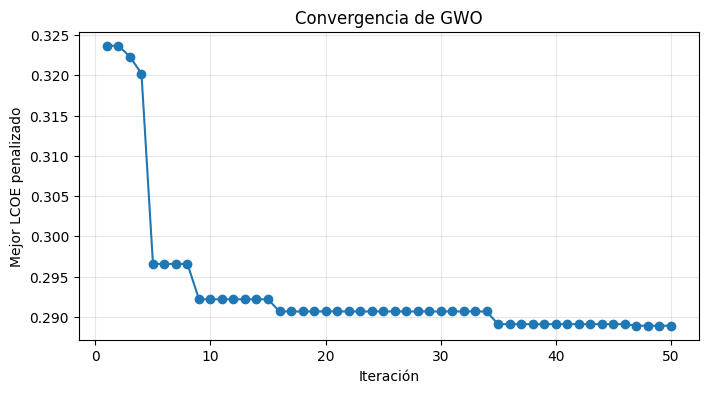

In [ ]:
plot_metaheuristic_history(history_gwo, "GWO")

### 5.3 - Resultado de PSO

In [ ]:
# ===== EJECUCIÓN DE PSO =====
history_pso, best_pso = pso_optimize_extend(
    df_year = df_tmy,
    config = CONFIG,
    costs = COSTS,
    n_particles = 20,
    n_iter = 50,
    w_min = 0.4,
    w_max = 0.9,
    c1 = 2.5,
    c2 = 1.0,
    seed = 42
)

history_pso.tail()

,iteration,best_score,wind_mw,pv_mw,electrolyzer_mw,n_el_units,battery_mw,battery_mwh,battery_duration_h,agsr,lcoe_cny_per_kwh,lcoh_cny_per_kg,feasible
45,46,0.2890,178.6150,21.3850,100.0000,20,35.0000,140.0000,4.0000,0.1995,0.2890,18.9882,True
46,47,0.2890,178.6150,21.3850,100.0000,20,35.0000,140.0000,4.0000,0.1995,0.2890,18.9882,True
47,48,0.2890,178.6150,21.3850,100.0000,20,35.0000,140.0000,4.0000,0.1995,0.2890,18.9882,True
48,49,0.2890,178.6150,21.3850,100.0000,20,35.0000,140.0000,4.0000,0.1995,0.2890,18.9882,True
49,50,0.2889,178.8599,21.1401,100.0000,20,35.0000,140.0000,4.0000,0.1999,0.2889,18.9914,True


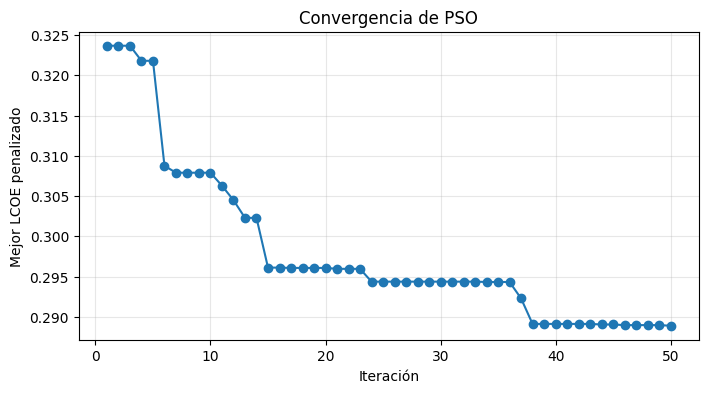

In [ ]:
plot_metaheuristic_history(history_pso, "PSO")

### 5.4 - Resultados de DE

In [ ]:
# ===== EJECUCIÓN DE DE =====
history_de, best_de = de_optimize_extend(
    df_year= df_tmy,
    config = CONFIG,
    costs = COSTS,
    n_candidates = 20,
    n_iter = 50,
    f_mutation = 0.8,
    cr = 0.9,
    seed = 42
)

history_de.tail()

,iteration,best_score,wind_mw,pv_mw,electrolyzer_mw,n_el_units,battery_mw,battery_mwh,battery_duration_h,agsr,lcoe_cny_per_kwh,lcoh_cny_per_kg,feasible
45,46,0.2889,178.9104,21.0896,100.0000,20,35.0000,140.0000,4.0000,0.1999,0.2889,18.9921,True
46,47,0.2889,178.9104,21.0896,100.0000,20,35.0000,140.0000,4.0000,0.1999,0.2889,18.9921,True
47,48,0.2889,178.9104,21.0896,100.0000,20,35.0000,140.0000,4.0000,0.1999,0.2889,18.9921,True
48,49,0.2889,178.9104,21.0896,100.0000,20,35.0000,140.0000,4.0000,0.1999,0.2889,18.9921,True
49,50,0.2889,178.9104,21.0896,100.0000,20,35.0000,140.0000,4.0000,0.1999,0.2889,18.9921,True


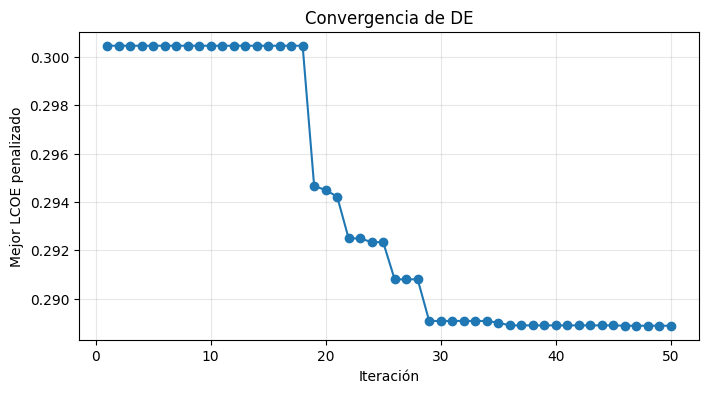

In [ ]:
plot_metaheuristic_history(history_de, "DE")

### 5.5 - Comparacion de resultados entre metaheuristcias

In [ ]:
resultados = []
for nombre, best in [("GWO", best_gwo), ("PSO", best_pso), ("DE", best_de)]:
    info = best["info"]
    resultados.append({
        "Algoritmo":       nombre,
        "LCOE (¥/kWh)":   info["lcoe_cny_per_kwh"],
        "LCOH (¥/kg)":    info["lcoh_cny_per_kg"],
        "Wind (MW)":       info["wind_mw"],
        "Elz. (MW)":       info["electrolyzer_mw"],
        "Bat. (MW)":       info["battery_mw"],
        "Bat. dur (h)":    info["battery_duration_h"],
        "AGSR":            info["agsr"],
        "CF Elz.":         info["electrolyzer_cf"],
        "Factible":        info["feasible"],
    })

pd.DataFrame(resultados).set_index("Algoritmo")

,LCOE (¥/kWh),LCOH (¥/kg),Wind (MW),Elz. (MW),Bat. (MW),Bat. dur (h),AGSR,CF Elz.,Factible
Algoritmo,,,,,,,,,
GWO,0.2889,18.9922,178.9223,100.0000,35.0000,4.0000,0.2000,0.5666,True
PSO,0.2889,18.9914,178.8599,100.0000,35.0000,4.0000,0.1999,0.5666,True
DE,0.2889,18.9921,178.9104,100.0000,35.0000,4.0000,0.1999,0.5666,True


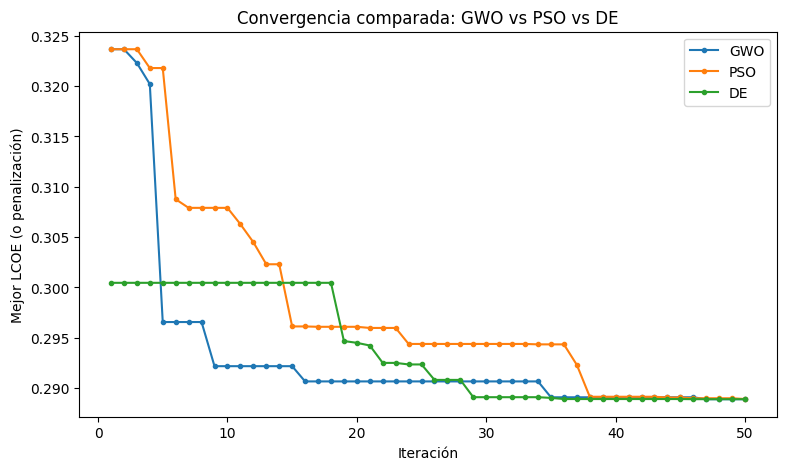

In [ ]:
plt.figure(figsize=(9, 5))
for nombre, hist in [("GWO", history_gwo), ("PSO", history_pso), ("DE", history_de)]:
    plt.plot(hist["iteration"], hist["best_score"], marker="o", markersize=3, label=nombre)
plt.xlabel("Iteración")
plt.ylabel("Mejor LCOE (o penalización)")
plt.title("Convergencia comparada: GWO vs PSO vs DE")
plt.legend()
plt.show()